Defaulting to user installation because normal site-packages is not writeable
ERROR: Could not find a version that satisfies the requirement talib (from versions: none)
ERROR: No matching distribution found for talib


/Users/akash/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
[*********************100%***********************]  1 of 1 completed
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(

[[0.47610436 0.52389564]
 [0.47248857 0.52751143]
 [0.4686487  0.5313513 ]
 ...
 [0.42457421 0.57542579]
 [0.42344514 0.57655486]
 [0.42559294 0.57440706]]
[1 1 1 ... 1 1 1]

Date(s) with Buy Signal(s):
2024-01-01
[1 1 1 ... 1 1 1]
[[  0 663]
 [  0 766]]
              precision    recall  f1-score   support

          -1       0.00      0.00      0.00       663
           1       0.54      1.00      0.70       766

    accuracy                           0.54      1429
   macro avg       0.27      0.50      0.35      1429
weighted avg       0.29      0.54      0.37      1429

[0.52830189 0.52830189 0.52830189 0.52941176 0.52941176 0.52941176
 0.52731092 0.52731092 0.52731092 0.52731092]
0.5282384651973997


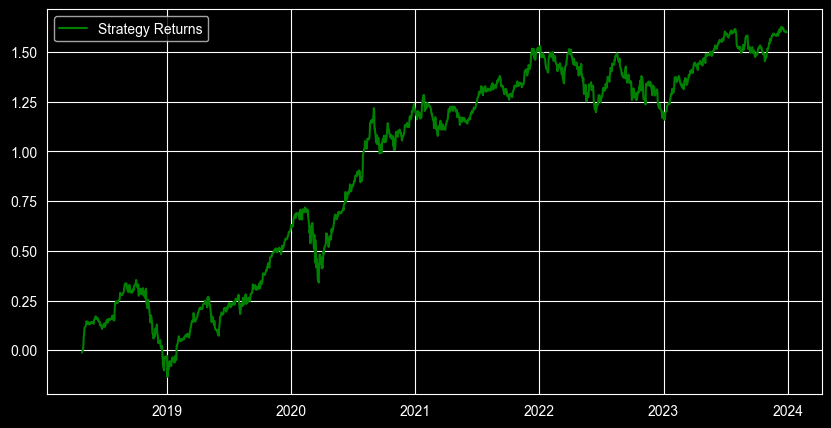

In [1]:
#!/usr/bin/env python
# coding: utf-8

# In[1]:


get_ipython().system('pip install talib as ta')

import talib as ta

# Data Manipulation
import numpy as np
import pandas as pd
import yfinance as yf

# Technical Indicators
import talib as ta

# Plotting graphs
import matplotlib.pyplot as plt

# Machine learning
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.model_selection import cross_val_score

# Pull AAPL data from Yahoo finance
df = yf.download('AAPL','2005-01-01', '2023-12-30', group_by='ticker')['AAPL']
df.tail()

df['S_10'] = df['Close'].rolling(window=10).mean()
df['Corr'] = df['Close'].rolling(window=10).corr(df['S_10'])
df['RSI'] = ta.RSI(df['Close'].values.reshape(-1,), timeperiod =10)
df['Open-Close'] = df['Open'] - df['Close'].shift(1)
df['Open-Open'] = df['Open'] - df['Open'].shift(1)
df = df.dropna()
X = df.iloc[:,:9]

y = np.where(df['Close'].shift(-1) > df['Close'],1,-1)

split = int(0.7*len(df))
X_train, X_test, y_train, y_test = X[:split], X[split:], y[:split], y[split:]

model = LogisticRegression()
model = model.fit (X_train,y_train)

pd.DataFrame(zip(X.columns, np.transpose(model.coef_)))

# Specify the start and end dates for prediction
start_date = '2019-12-22'
end_date = '2024-01-01'

# Create a list containing the start and end dates
prediction_date = [start_date, end_date]

# Use the list of dates for prediction
probability = model.predict_proba(X_test)
print(probability)

predicted = model.predict(X_test)

print (predicted)

# Define predicted_labels as buy signal (1)
predicted_labels = 1

# Find the dates with predicted buy signals (Signal = 1)
buy_signal_dates = prediction_date[predicted_labels == 1]

# Print the date(s) with buy signal(s)
print("\nDate(s) with Buy Signal(s):")
print(buy_signal_dates)
print(predicted)

print(metrics.confusion_matrix(y_test, predicted))

print(metrics.classification_report(y_test, predicted))

cross_val = cross_val_score(LogisticRegression(), X, y, scoring='accuracy', cv=10)
print(cross_val)
print(cross_val.mean())

df['Predicted_Signal'] = model.predict(X)
df['AAPL_returns'] = np.log(df['Close']/df['Close'].shift(1))
Cumulative_Nifty_returns = np.cumsum(df[split:]['AAPL_returns'])

df['Strategy_returns'] = df['AAPL_returns']* df['Predicted_Signal'].shift(1)
Cumulative_Strategy_returns = np.cumsum(df[split:]['Strategy_returns'])

plt.figure(figsize=(10,5))
plt.plot(Cumulative_Strategy_returns, color='g', label = 'Strategy Returns')
plt.legend()
plt.show()


# In[ ]:




